# Demand and Priors Graphs

* Imports
* Demand
* Demand Graphs
* Economics: Price, Demand, Revenue, Profit
* Demand Log Normal
* Priors $a$, $v$, $\sigma$


# Imports

In [1]:
# Good to know the Python version
!python --version

Python 3.12.7


In [2]:
# General Imports
import numpy as np
import pandas as pd
import beautifulplots as bp
import matplotlib.pyplot as plt

import pymc as pm
from math import ceil

import random

# Set Seed
np.random.seed(42) # keeps stats numbers repeatable ... convenientfor initial development

# Demand

In [3]:
example_case = "case2"

variable_cost = 1.2
fixed_cost = 6
v_true = 1.8
a_true = 4000

# set demand variables
# also set some simulation variables ... this is a convenient place
#   to keep from repeating code logic

# low variability
if example_case == "case1": # hard example 
    CV_true = .05
    sigma_log_true = np.sqrt(np.log1p(CV_true**2)) # sqrt(1 + CV^2)
    p1 = 3.6 # w sigma_log .04 can be further away from optimal price

elif example_case == "case2": # medium difficutlty
    CV_true = .20
    sigma_log_true = np.sqrt(np.log1p(CV_true**2)) # sqrt(1 + CV^2)
    p1 = 3.6  # w sigma_log .15 need to be closer to target
    Nrounds = 100

elif example_case == "case3" : # hard
    CV_true = .30
    sigma_log_true = np.sqrt(np.log1p(CV_true**2)) # sqrt(1 + CV^2)
    p1 = 3.6

else:   # default to None
    v_true = None
    a_true = None
    sigma_log_true = None
    variable_cost = None
    fixed_cost = None
    p1 = None

    
#m_log = a_true + p1 ** (-v_true) # logD before additive noise
#d1m =  a_true * p1 ** (-v_true) * np.exp(sigma_log_true**2 / 2) # E[D] at p1

# p1 = 3.6 corresponds to an initial guess of v = 1.5 with variable cost of 1.2

def print_demand_vars():
    print("DEMAND VARIABLES")
    print(f'  v_true = {v_true}')
    print(f'  a_true = {a_true}')
    print(f'  CV_true = {CV_true}')
    print(f'  sigma_log_true = {round(sigma_log_true,2)}')
    print(f'  variable_cost = {variable_cost}')
    print(f'  fixed_cost = {fixed_cost}')
    print(f"  p1 (initial price point) = {p1}")
    #print(f"  d1m = (E[D] at p1) = {round(d1m,2)}")
    
print_demand_vars()


DEMAND VARIABLES
  v_true = 1.8
  a_true = 4000
  CV_true = 0.2
  sigma_log_true = 0.2
  variable_cost = 1.2
  fixed_cost = 6
  p1 (initial price point) = 3.6


#### Derived Parameters

In [49]:
# derived parameters

if v_true <= 1:
    p_opt  = variable_cost 
else:
    p_opt = (v_true / (v_true - 1)) * variable_cost
    
D_opt = a_true * p_opt **(-v_true)
Profit_opt = p_opt * D_opt - variable_cost * D_opt - fixed_cost  
D_true_p1= a_true * p1 **(-v_true)
Profit_p1 = p1* D_true_p1 - variable_cost * D_true_p1 - fixed_cost
    

# noise inflation term
e_term = np.exp(sigma_log_true**2 / 2)
D_opt_mean = D_opt * e_term
profit_p1_mean = p1 * D_true_p1 * e_term - variable_cost * D_true_p1 * e_term - fixed_cost
    
print("price optimum")
print(f'  p_opt = {round(p_opt,2)}, ... optimal price given true params')
print("median")    
print(f'  D_opt = {round(D_opt,2)}, ... optimal demand given true params')
print(f'  Profit_opt = {round(Profit_opt,2)}, ... optimal profit given true params')
print(f'  D_true_p1 = {round(D_true_p1,2)}, ... demand true Mean at p1 = {round(p1,2)}')
print(f'  Profit_p1 = {Profit_p1}')

print("mean")
print(f'  D_opt_mean = {round(D_opt_mean,2)}, ... optimal demand mean given true params')
print(f'  Profit_p1_mean = {round(profit_p1_mean,2)}, ... mean profit at p1 = {round(p1,2)}')



price optimum
  p_opt = 2.7, ... optimal price given true params
median
  D_opt = 669.28, ... optimal demand given true params
  Profit_opt = 997.91, ... optimal profit given true params
  D_true_p1 = 398.76, ... demand true Mean at p1 = 3.6
  Profit_p1 = 951.0325999671358
mean
  D_opt_mean = 682.53, ... optimal demand mean given true params
  Profit_p1_mean = 969.99, ... mean profit at p1 = 3.6


In [5]:
# Profit_p1 =  (p1 - ) * D_true_p1

total_costs_per_unit_p1 = variable_cost + fixed_cost/D_true_p1
print(f'total_costs_per_unit_p1 = {round(total_costs_per_unit_p1,2)}')

total_costs_per_unit_popt = variable_cost + fixed_cost/D_opt
print(f'total_costs_per_unit_popt = {round(total_costs_per_unit_popt,2)}')

total_costs_per_unit_p1 = 1.22
total_costs_per_unit_popt = 1.21


#### Model Input Parameters

In [13]:
# Prior a hyperparameters
  #   - important, can get large and blow things out
  #   - careful with  CV = sigma_a / mu_a
  #   - CV = 0.2 tight good (sigma_a = 600/3000), 
  #   - CV = 0.4 = reasonable, well behaved posterior

CV_a = 0.05 # = sigma_linear / mu_linear
m_a_linear  = a_true -100
sigma_a_linear =  CV_a * m_a_linear
sigma_a = np.sqrt(np.log(1 + CV_a**2))
m_a = round(np.log(m_a_linear) - 0.5 * sigma_a**2, 2)

# Prior v hyperparameters 
   #  - ecommerce demand [1.4 , 1.8]
   #  -  sigma_v .3 to .4 good
   #  - sigma_v  0.5 noisy demand ... borderline large
   #  - values near 1 can cause large price swings
   #  - truncated notrmal lower_v hyper ... prevent gettng too close to 1
   # parameters ... m_vtn, signma_v
   
m_v, sigma_v = 1.5, 0.4    #  hyperparameters for prior v
lower_v = 1.1
upper_v = np.inf

if example_case == "case1":
    CV = .06 # prior hyperparameter
    sigma_log = np.sqrt(np.log1p(CV**2)) # sqrt(1 + CV^2)
elif example_case == "case2":
    CV = .18 # prior hyperparameter
    sigma_log = np.sqrt(np.log1p(CV**2)) # sqrt(1 + CV^2)
elif example_case == "case3":
    CV = .4 # prior hyperparameter
    sigma_log = np.sqrt(np.log1p(CV**2)) # sqrt(1 + CV^2)
else:
    CV = None
    sigma_log = None

price_min = 2
price_max = 4.0

def print_hyper_params():
    hyper_param_str = f"""
Model Input Parameters
  CV_a = {CV_a}, m_a_linear = {m_a_linear}, sigma_a_linear = {sigma_a_linear}
     m_v = {m_v}, sigma_a = {round(sigma_a,4)}
  m_v {m_v}, sigma_v = {sigma_v}, lower_v = {lower_v}
  CV = {CV}, sigma_log = {round(sigma_log,4)}
  price_min = {price_min}
  price_max = {price_max} """
    
    print(hyper_param_str)


print_hyper_params()


Model Input Parameters
  CV_a = 0.05, m_a_linear = 3900, sigma_a_linear = 195.0
     m_v = 1.5, sigma_a = 0.05
  m_v 1.5, sigma_v = 0.4, lower_v = 1.1
  CV = 0.18, sigma_log = 0.1786
  price_min = 2
  price_max = 4.0 


# Demand Graph

In [14]:
from utils_probability import demand_sample

In [15]:
N_samples = 300

print(f'a_true = {a_true}')
print(f'v_true = {v_true}')
print(f'sigma_log_true = {sigma_log_true}')
print(f'p1 = {p1}')
print(f'N_samples = {N_samples}')

print()
y_p1 = demand_sample(p1, a_true, v_true, sigma_log_true, size=N_samples)

y_p_opt = demand_sample(p_opt, a_true, v_true, sigma_log_true, size=N_samples)

print()
#print(f'y = {y}')
df_y_samples = pd.DataFrame({ 't' :range(1,N_samples + 1)  ,'y_p1': y_p1, 'y_p_opt':y_p_opt})


a_true = 4000
v_true = 1.8
sigma_log_true = 0.19804220043536505
p1 = 3.6
N_samples = 300




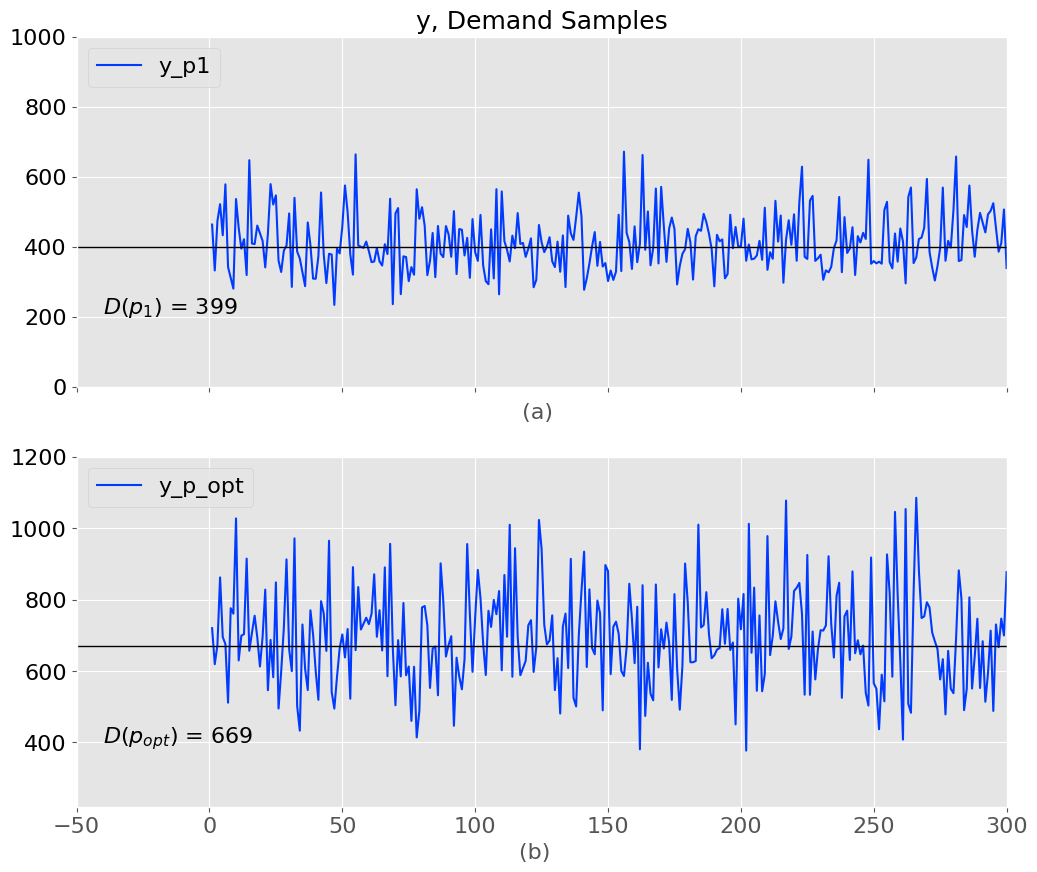

In [47]:

fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(12,10))
#df_y_samples["y_p0"] = df_y_samples["y_p1"]

label_and_graph_no_str = """ (a)  """
bp.lineplot(df_y_samples,x = "t", y='y_p1', title='y, Demand Samples', xlabel='Demand',
            x_axis_label = label_and_graph_no_str ,y_axis_format=".0f", color='#013BFF', h_line=D_true_p1, y_lims = (0,1000), x_lims=(-50,300),
            legend_loc = "upper left",
         annotate=[(f"$D(p_1)$ = {round(D_true_p1)}",(-40,210))],
         ax = axs[0] )
axs[0].set_xticklabels([])
#axs[0].get_legend().set_visible(False)

label_and_graph_no_str = """(b)  """
bp.lineplot(df_y_samples,x = "t", y=f'y_p_opt',  xlabel='Demand',y_axis_format=".0f", 
        x_axis_label = label_and_graph_no_str,
        color='#013BFF', h_line=D_opt, y_lims = (220,1200),  x_lims=(-50,300),
        annotate=[("$D(p_{opt})$ = "+ f'{round(D_opt)}',(-40,400))],
        ax = axs[1] )



plt.subplots_adjust(hspace=.2, wspace=0.1)
plt.show()


# Economics: Price, Demand, Revenue, Profit

In [17]:
# Revenue and Profit ... MR and MC .... y2 legend location
p = np.linspace(1, 10, 100)
D = a_true * p **(-v_true)  # Demand
R = p * D  # Revenue
TC = fixed_cost + variable_cost * D   # Total Cost
ACPU =   ( fixed_cost / a_true ) * (p ** v_true) + variable_cost  # = TC / D ... average cost per Unit
P = R - TC # Profit
RPU = R / D # Revenue per Unit
MR = p * (1 - 1/ v_true) #
MC = variable_cost # Marginal Cost
ACPU_p_opt = (fixed_cost + variable_cost * D_opt ) / D_opt # NOTE: ACPU is not exactly = MC 
TC_p_opt = fixed_cost + variable_cost * D_opt
D_p1 = a_true * p1 **(-v_true)
TC_p1 = fixed_cost + variable_cost * D_p1

Profit_opt = D_opt * p_opt - TC_p_opt

print(f'p1 = {p1}, ... Initial Price Point')
print(f'D_p1 = {round(D_p1,2)}, ... Mean Demand at Initial Price Point')
print(f'TC_p1 = {TC_p1}, ...  Total Cost at initial price point')
print(f'p_opt = {round(p_opt,2)}, ... Optimal Price Point')
print(f'D_opt = {round(D_opt,2)}, ... Demand at optmal price point')
print(f'TC_p_opt = {TC_p_opt}, ...  Total Cost at optmal price point')
print(f'ACPU_p_opt = {ACPU_p_opt}, ... Avg Cost per Unit at optmal price point')
print(f'Profit_opt = {Profit_opt}, ... Profit at optmal price point')

print()
print('df_demand_profit')
df_demand_profit = pd.DataFrame({'price': p, 'demand': D, 'revenue':R, 'costs': TC, 'profit': P, "acpu":ACPU ,"mr":MR, "mc":MC }) 

df_demand_profit[df_demand_profit['price'] > 1].head(10)

p1 = 3.6, ... Initial Price Point
D_p1 = 398.76, ... Mean Demand at Initial Price Point
TC_p1 = 484.5162999835678, ...  Total Cost at initial price point
p_opt = 2.7, ... Optimal Price Point
D_opt = 669.28, ... Demand at optmal price point
TC_p_opt = 809.131133805389, ...  Total Cost at optmal price point
ACPU_p_opt = 1.208964912075921, ... Avg Cost per Unit at optmal price point
Profit_opt = 997.9139172567361, ... Profit at optmal price point

df_demand_profit


,price,demand,revenue,costs,profit,acpu,mr,mc
1,1.090909,3420.113996,3731.033450,4110.136795,-379.103345,1.201754,0.484848,1.2
2,1.181818,2961.207158,3499.608459,3559.448589,-59.840130,1.202026,0.525253,1.2
3,1.272727,2591.411373,3298.159929,3115.693647,182.466282,1.202315,0.565657,1.2
4,1.363636,2288.772140,3121.052918,2752.526567,368.526350,1.202621,0.606061,1.2
5,1.454545,2037.749784,2963.999686,2451.299741,512.699945,1.202944,0.646465,1.2
6,1.545455,1827.085059,2823.676909,2198.502071,625.174838,1.203284,0.686869,1.2
7,1.636364,1648.452037,2697.466969,1984.142444,713.324525,1.203640,0.727273,1.2
8,1.727273,1495.582390,2583.278674,1800.698868,782.579806,1.204012,0.767677,1.2
9,1.818182,1363.681135,2479.420245,1642.417361,837.002883,1.204400,0.808081,1.2
10,1.909091,1249.027769,2384.507560,1504.833323,879.674237,1.204804,0.848485,1.2


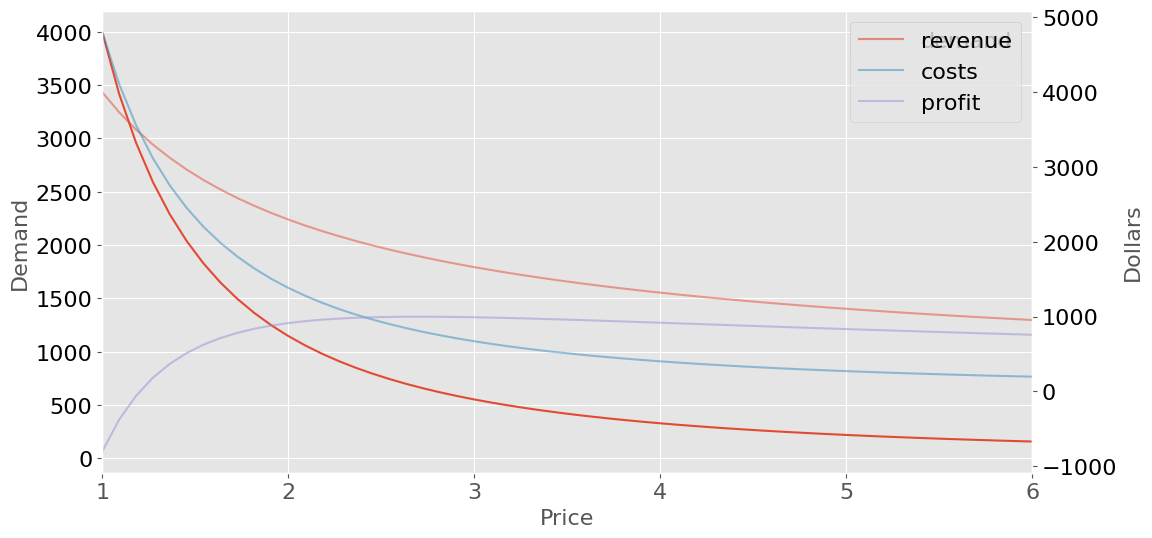

In [18]:

# Plot Demand, Revenue, Costs, Profit vs Price
bp.lineplot(df_demand_profit, 
    x="price",
    y2 = ["revenue", "costs" ,"profit"],
    y = "demand",
    y_axis_label='Demand',
    y_axis_format=".0f",
    y2_axis_label='Dollars',
    y2_axis_format=".0f",
    x_axis_label='Price',
    figsize=(12,6),
    x_lims=(1, 6)
    )

<>:10: SyntaxWarning: invalid escape sequence '\$'
<>:37: SyntaxWarning: invalid escape sequence '\_'
<>:10: SyntaxWarning: invalid escape sequence '\$'
<>:37: SyntaxWarning: invalid escape sequence '\_'
/var/folders/mv/q8fjq_112p3cn5zntkpq1rjw0000gn/T/ipykernel_71799/4112001765.py:10: SyntaxWarning: invalid escape sequence '\$'
  title  = f"Demand, revenue, costs, profit at $p_1$ = \${round(p1,2)}",
/var/folders/mv/q8fjq_112p3cn5zntkpq1rjw0000gn/T/ipykernel_71799/4112001765.py:37: SyntaxWarning: invalid escape sequence '\_'
  title  = f"Demand, revenue, costs, profit at $p\_opt$ = \${round(p_opt,2)}",


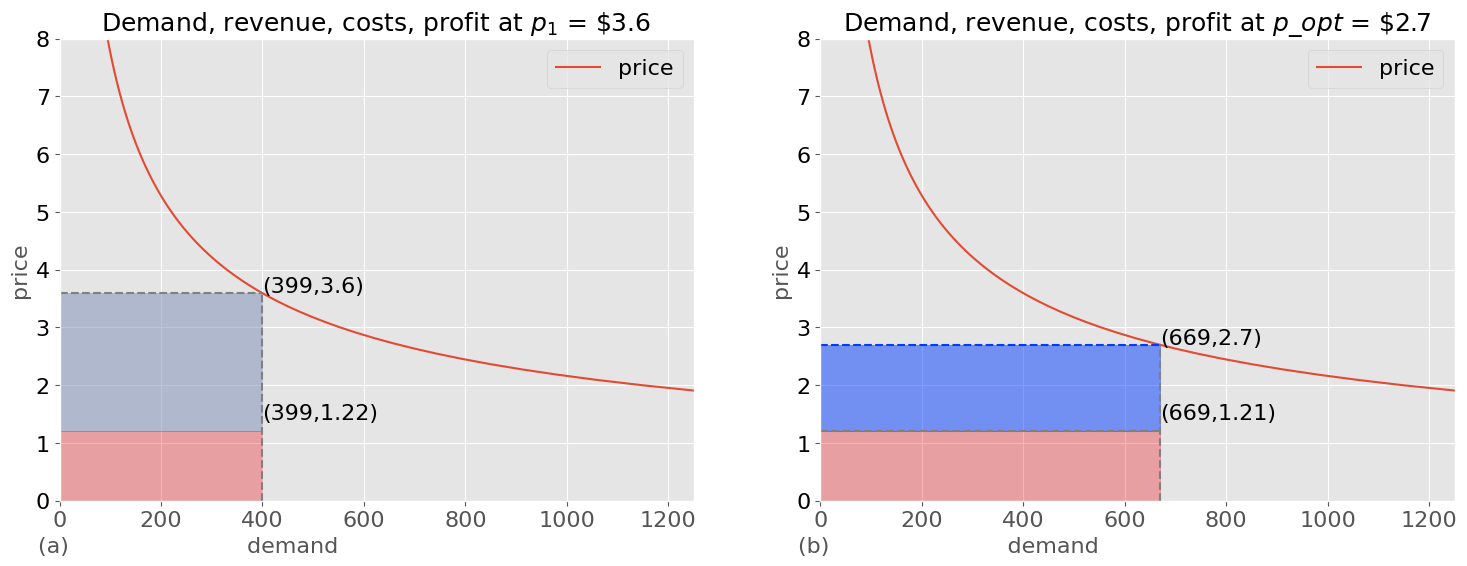

Fig 2: Price, MR, MC vs Demand 


In [50]:
# Print 
fig, axs = plt.subplots(nrows=1,ncols=2, figsize=(18,6))

# Price Demand
bp.lineplot(df_demand_profit, x='demand', y="price", 
            y_axis_format=".0f",  
            x_axis_label='(a)                         demand                                                     ', 
            y_axis_label="price",x_lims=(0,1250 ), y_lims = (0,8),    
            figsize=(12,6), 
            title  = f"Demand, revenue, costs, profit at $p_1$ = \${round(p1,2)}",
            annotate = [(f"({round(D_true_p1)},{round(p1,2)})",(D_true_p1,p1)),
               (f"({round(D_true_p1)},{round(total_costs_per_unit_p1,2)})", (D_true_p1,total_costs_per_unit_p1 + .2))],
            ax=axs[0])

# Starting Pice and Demand Points
axs[0].hlines(y=p1, xmin=0, xmax=D_p1, linestyles='dashed', color='gray')
axs[0].vlines(x=D_p1, ymin=0, ymax=p1,  linestyles='dashed', color='gray')

# p1 profit area
x = np.linspace(0, D_p1, 200)
y_lower = np.full_like(x,TC_p1/D_p1)  # curve 1: y = TC per unit at p1
y_upper = np.full_like(x, p1)    # curve 2: y = p_opt
axs[0].fill_between( x=x,  y1=y_lower, y2=y_upper,   color="#7B8CB4", alpha=0.5) # revenue area

# Cost area at p1
y_lower = np.full_like(x,0)        # curve 1: y = 0
y_upper = np.full_like(x, total_costs_per_unit_p1)  # curve 2: y = TC per unit at p_opt
axs[0].fill_between( x=x,  y1=y_lower, y2=y_upper,   color="#F10007", alpha=0.3) # cost area


# Price Demand 
bp.lineplot(df_demand_profit, x='demand', y="price", 
            y_axis_format=".0f",  
            x_axis_label='(b)                         demand                                                     ', 
            y_axis_label="price",x_lims=(0,1250 ), y_lims = (0,8),    
            figsize=(12,6), 
            title  = f"Demand, revenue, costs, profit at $p\_opt$ = \${round(p_opt,2)}",
            annotate = [(f"({round(D_opt)},{round(p_opt,2)})",(D_opt,p_opt)),
               (f"({round(D_opt)},{round(total_costs_per_unit_popt,2)})", (D_opt,total_costs_per_unit_popt + .2))],
            ax=axs[1])


# Optimal Price, Demand Lines, Total Cost
axs[1].hlines(y=p_opt, xmin=0, xmax=D_opt, linestyles='dashed', color='#013BFF')
axs[1].hlines(y=total_costs_per_unit_popt, xmin=0, xmax=D_opt,  linestyles='dashed', color='gray')
axs[1].vlines(x=D_opt, ymin=0, ymax=p_opt, linestyles='dashed', color='gray')

# - Optimal Profit Area
x = np.linspace(0, D_opt, 200)
y_lower = np.full_like(x,total_costs_per_unit_popt)          # y = 0
y_upper = np.full_like(x, p_opt)    #  y = p_opt
axs[1].fill_between( x=x,  y1=y_lower, y2=y_upper,   color="#013BFF", alpha=0.5) # revenue area

# Cost area at optimal price
y_lower = np.full_like(x,0)        # curve 1: y = 0
y_upper = np.full_like(x, total_costs_per_unit_popt)  # curve 2: y = TC per unit at p_opt
axs[1].fill_between( x=x,  y1=y_lower, y2=y_upper,   color="#F10007", alpha=0.3) # cost area


plt.show()

print(f"""Fig 2: Price, MR, MC vs Demand """)

# Demand Log Normal

In [21]:
from utils_probability import demand_lognormal_pdf

d = np.linspace(100,2000,500)

# log D is Normal, then D is logNormal
# dispersion of demand is controlled by sigma_log, which is the standard deviation of log D
# CV is converted to sigma_log in the function
# sigma_log = np.sqrt(np.log1p(CV**2)) # sqrt(1 + CV^2)
# mu = np.log(a) - v * np.log(p_opt) ... this is the log of the mean demand at p_opt
density_d = demand_lognormal_pdf(d, a_true, v_true, p1, CV_true)

df_prob_demand = pd.DataFrame({"demand likelihood":d, "prob_demand": density_d})

max_index = df_prob_demand["prob_demand"].idxmax() # index of max probability

print(f'max_index = {max_index}')

df_prob_demand.loc[max_index-3:max_index+3]

max_index = 74


,demand likelihood,prob_demand
71,370.340681,0.005073
72,374.148297,0.005112
73,377.955912,0.005138
74,381.763527,0.005150
75,385.571142,0.005150
76,389.378758,0.005136
77,393.186373,0.005110


In [22]:
# D_mode corresponds to the center of the statistical demand function

D_mode_p1 = a_true * p1 **(-v_true) * np.exp(- sigma_log_true**2)  # mode of lognormal distribution

print(f'D_mode = {round(D_mode_p1,2)}')

D_mode = 383.43


<>:19: SyntaxWarning: invalid escape sequence '\$'
<>:19: SyntaxWarning: invalid escape sequence '\$'
/var/folders/mv/q8fjq_112p3cn5zntkpq1rjw0000gn/T/ipykernel_71799/1983945205.py:19: SyntaxWarning: invalid escape sequence '\$'
  y_axis_label=f"f(D, $p_1$ \${round(p1,2)})",


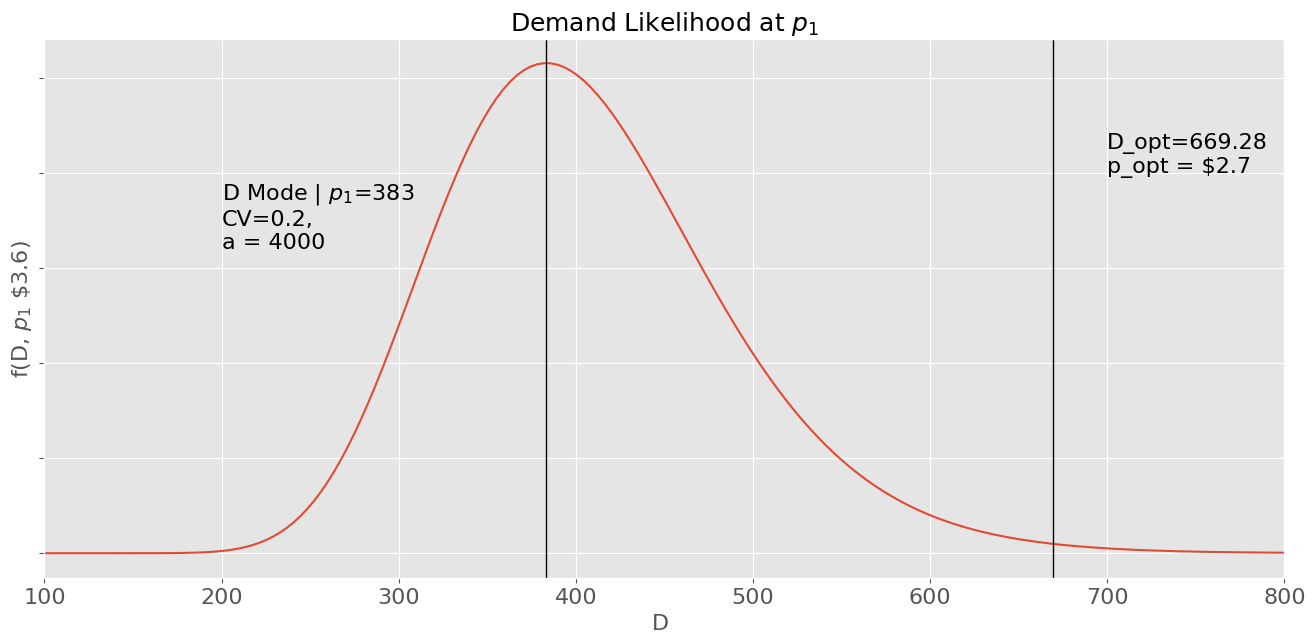

In [32]:
## Graph Demand Likelihood
# 2 x2 subplots
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(16, 7))

#----- Probability Demand Likelihood, LogNormal -----
label_and_graph_no_str = """D """
bp.lineplot(df_prob_demand, 
    x='demand likelihood', 
    y=['prob_demand'],  
    x_axis_label=label_and_graph_no_str, 
    legend = False,
    title = "Demand Likelihood at $p_1$",
    annotate = [  
        (f"D Mode | $p_1$={round(D_mode_p1)}\nCV=0.2,\na = 4000",(200,.0032)),
        (f"D_opt={round(D_opt,2)}\np_opt = ${round(p_opt,2)}",(700, 0.004)),
           ],
    v_line = [D_mode_p1,D_opt],
    x_lims = (100, 800),
    y_axis_label=f"f(D, $p_1$ \${round(p1,2)})", 
    ax = axs )

axs.tick_params(axis='y', labelleft=False)
plt.show()

# Priors - a , v, $\sigma$

Prior a
* prioir is precisely modeled in log-space, log a. 
* For easier interpretability we caclulate and graph a

In [24]:
# Shaping Parameter Prior a
# Lognormal

from utils_probability import lognormal_pdf

print("hyperparameters for prior a (lognormal)")
print(f'CV_a = {CV_a}')
print(f'mu_a = {m_a}')
print(f'sigma_a = {sigma_a}')

a = np.linspace(1,10000, 400)

prob_a = lognormal_pdf(x=a, m=m_a, sigma=sigma_a)

# find mid_point values ... to get sense of numbers
mid_a=int(np.floor(len(a)/2).item())
mid_prob = int(prob_a[mid_a].item())
df_prob_a = pd.DataFrame({'a': a, 'prob_a': prob_a})

print(f'prob_a_mid({mid_a}) = {prob_a[mid_a]}')
print(df_prob_a["prob_a"].sum())


hyperparameters for prior a (lognormal)
CV_a = 0.05
mu_a = 8.27
sigma_a = 0.049968792246632754
prob_a_mid(200) = 5.963783577444756e-09
0.03990399039903993


<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\_'
<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\_'
/var/folders/mv/q8fjq_112p3cn5zntkpq1rjw0000gn/T/ipykernel_71799/3659316121.py:12: SyntaxWarning: invalid escape sequence '\m'
  annotate = [(f"Input parameters\n  $\mu_a\_linear$ = {round(m_a_linear)}\n  $CV_a$ = .05",
/var/folders/mv/q8fjq_112p3cn5zntkpq1rjw0000gn/T/ipykernel_71799/3659316121.py:14: SyntaxWarning: invalid escape sequence '\_'
  (f"$a\_true$ = {a_true}",(4200, .0014)),


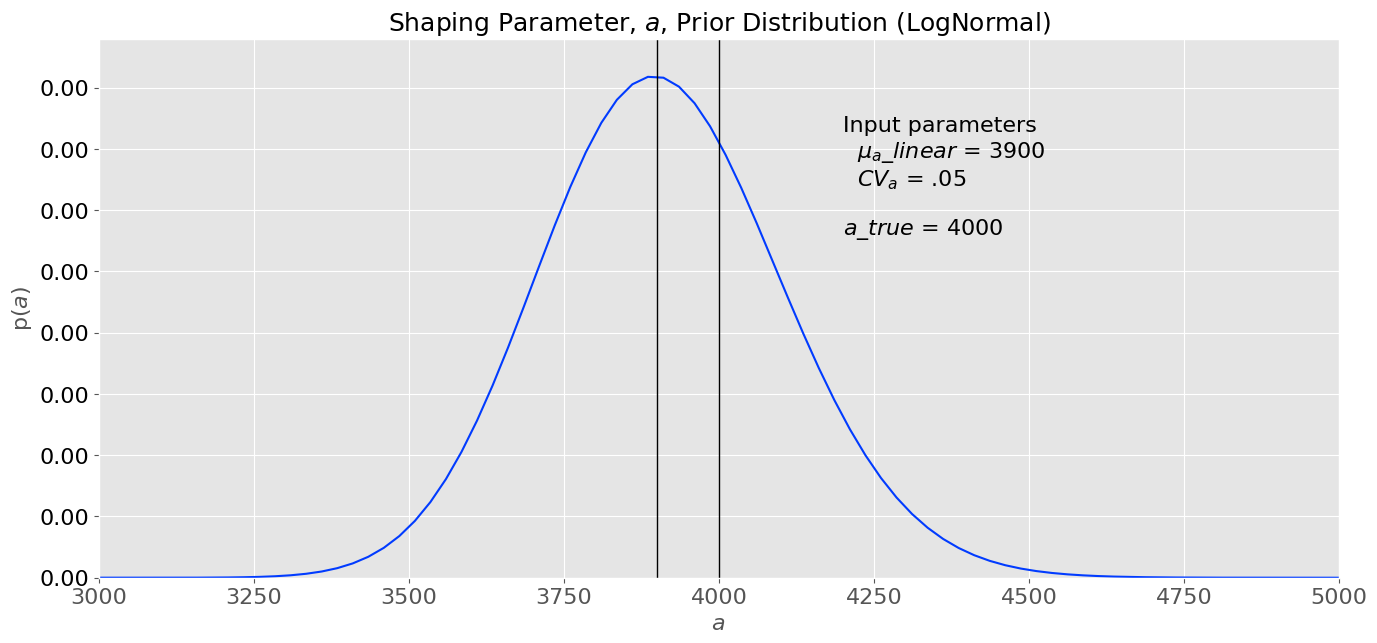

In [25]:
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(16, 7))

#-------------  Prior a -------------
#  lognormal
label_and_graph_no_str = """$a$ """
bp.lineplot(df_prob_a, x='a', y='prob_a', 
            x_axis_label=label_and_graph_no_str, 
        v_line = [m_a_linear, a_true],
        legend = False,
        y_axis_label='p($a$)', 
        title = "Shaping Parameter, $a$, Prior Distribution (LogNormal)",
        annotate = [(f"Input parameters\n  $\mu_a\_linear$ = {round(m_a_linear)}\n  $CV_a$ = .05",
                    (4200, .0016)),
                    (f"$a\_true$ = {a_true}",(4200, .0014)),
                ],
        x_lims = (3000,5000),
        y_lims = (0, .0022),
        ax = axs, color='#013BFF'
        )
plt.show()

Prior v
- truncated Normal
- the translation of normal to truncated normal shifts the respective mean

In [28]:
# Prior v 
#  v = demand elasticity
#  truncated_normal
from utils_probability import truncated_normal_pdf, truncated_normal_mean

# - since v = 1 is a discontinuity 
# - therefore, lower truncated normal for prior v
# - lower limit = 1.1 
# - mean of 1.5 here is an effecitve mean of 1.6
m_vtn = truncated_normal_mean(mu=m_v, sigma=sigma_v, a=lower_v)
vtn_true = truncated_normal_mean(mu=v_true, sigma=sigma_v, a=lower_v)
print(f'm_v = {m_v}')
print(f'sibma_v = {sigma_v}')

# example inputs
v = np.linspace(lower_v, 4, 100)

# prob_v
prob_v = truncated_normal_pdf(
                x=v,    
                m=m_v,  
                sigma=sigma_v,  
                lower_limit=lower_v, 
                upper_limit=upper_v
          )

# Elasticiay Parameter Prior
df_prob_v = pd.DataFrame({'v': v, 'prob_v': prob_v})



m_v = 1.5
sibma_v = 0.4


<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\_'
<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\_'
/var/folders/mv/q8fjq_112p3cn5zntkpq1rjw0000gn/T/ipykernel_71799/3389841602.py:9: SyntaxWarning: invalid escape sequence '\m'
  (f"Input Parameters\n  $\mu_v$={round(m_v,2)}\n  $\sigma_v$ = .4\n  $v_{{min}}$ = 1.1", (2,.75)),
/var/folders/mv/q8fjq_112p3cn5zntkpq1rjw0000gn/T/ipykernel_71799/3389841602.py:9: SyntaxWarning: invalid escape sequence '\s'
  (f"Input Parameters\n  $\mu_v$={round(m_v,2)}\n  $\sigma_v$ = .4\n  $v_{{min}}$ = 1.1", (2,.75)),
/var/folders/mv/q8fjq_112p3cn5zntkpq1rjw0000gn/T/ipykernel_71799/3389841602.py:10: SyntaxWarning: invalid escape sequence '\_'
  (f"$v\_true$ = {round(v_true,2)}" ,(2, .6)),


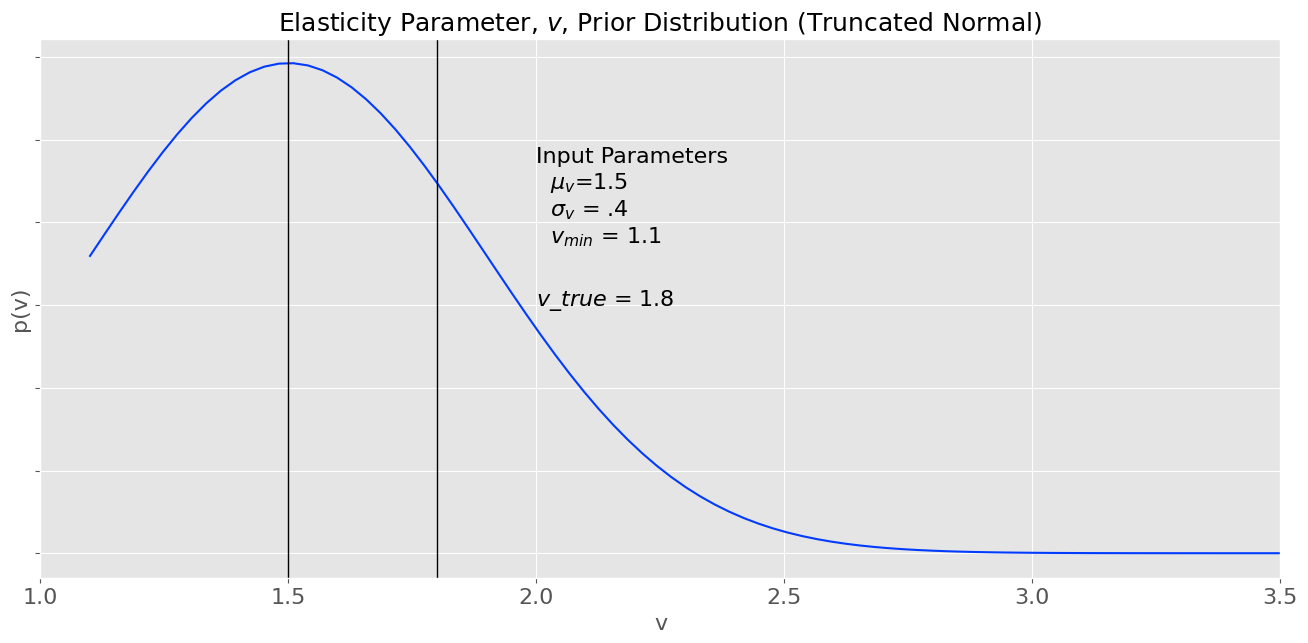

In [30]:

fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(16, 7))

#--------- Prior v  ----------------
label_and_graph_no_str = """v"""
bp.lineplot(df_prob_v, x='v', y='prob_v',  x_axis_label=label_and_graph_no_str,
legend = False,
title = "Elasticity Parameter, $v$, Prior Distribution (Truncated Normal)",
annotate = [
            (f"Input Parameters\n  $\mu_v$={round(m_v,2)}\n  $\sigma_v$ = .4\n  $v_{{min}}$ = 1.1", (2,.75)),
            (f"$v\_true$ = {round(v_true,2)}" ,(2, .6)),
            ],
y_axis_label='p(v)', ax = axs, 
v_line = [m_v,v_true],
x_lims = [1, 3.5],
color='#013BFF')
axs.tick_params(axis='y', labelleft=False)


plt.show()

Prior sigma_log
* CV is the coeficient of variaion of demand, D
* We are not modeling noise/sigma_log as probabilistic prior
- Though initially we did. This graph is thus interesting but not of real use
- The sigma_log hyperparameter is currently constant
* standard deviation of log D, sigma_log = $\sqrt{1 + CV^2}$ 

In [46]:
# Prior sigma_log
# sigma_log = sqrt(1+ CV^2)
# half-normal
from utils_probability import  half_normal_pdf
# PyMC half normal ... for paramter sigma_log
#    if want a, "mean" (offse) then need to add offset constant

sigma_log = np.sqrt(np.log1p(CV**2)) # sigma_log derived from CV, hyperparameter
mu_hn = sigma_log * np.sqrt(2/np.pi) # mu_hn this is not an input to the half normal. It is convenient for graphing later.


_sigma_log = np.linspace(1e-6, .5, 100)
prob_sigma_log = half_normal_pdf(_sigma_log, sigma=sigma_log)

# convienent to get some values for the densities
mid_sigma_log =int(np.floor(len(_sigma_log)/2).item())

df_prob_sigma_log = pd.DataFrame({'sigma': _sigma_log, 'prob_sigma': prob_sigma_log})

p_sigma_log_density = np.interp(sigma_log, _sigma_log, prob_sigma_log)

print(f'sigma_log = {sigma_log}')
print(f'prob_density(sigma_log) = {p_sigma_log_density}')


# trapezpoid takes the average of the two endpoints of each interval, 
# multiplies by the width of the interval, and sums these products to get 
# an approximation of the area under the curve.
area_sigma_log=np.trapezoid(prob_sigma_log, _sigma_log)
print(f'area_sigma_log = {area_sigma_log}')

# density starts large and gets small fast
df_prob_sigma_log.head(5)


sigma_log = 0.17856704304636326
prob_density(sigma_log) = 2.7101400107619606
area_sigma_log = 0.9948834056615505


,sigma,prob_sigma
0,0.000001,4.468263
1,0.005051,4.466476
2,0.010102,4.461119
3,0.015152,4.452205
4,0.020203,4.439757


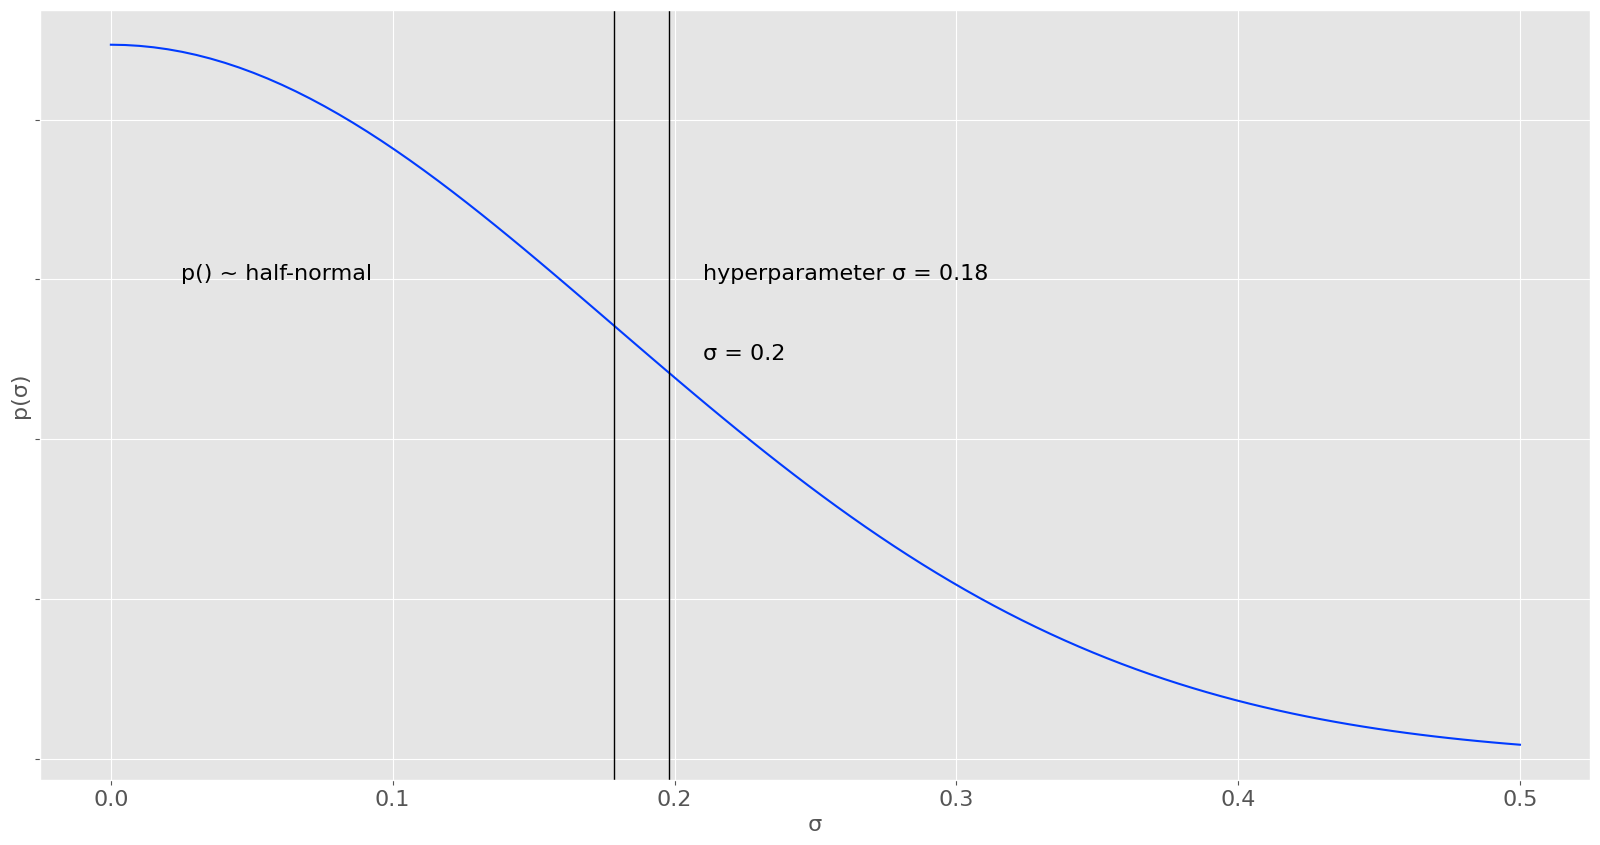

In [114]:
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(20, 10))
#----------- Prior sigma_log, subplot (sigma_log) -----------
label_and_graph_no_str = """ σ """
bp.lineplot(df_prob_sigma_log, x='sigma', y='prob_sigma', x_axis_label=label_and_graph_no_str,
legend = False,
y_axis_label='p(σ)', 
v_line = [sigma_log_true, sigma_log],
ax = axs, 
annotate = [   ( ("p() ~ half-normal"), (0.025, 3)),
               (f"σ = {round(sigma_log_true,2)}", (.21,2.5)),
               (f"hyperparameter σ = {round(sigma_log,2)}", (.21,3))
             ],
color='#013BFF')
axs.tick_params(axis='y', labelleft=False)

plt.show()